In [2]:
import pandas as pd

# load dataset
data = pd.read_csv("data/continuous dataset.csv")

# show first rows
print(data.head())

              datetime  nat_demand    T2M_toc  QV2M_toc   TQL_toc    W2M_toc  \
0  2015-01-03 01:00:00    970.3450  25.865259  0.018576  0.016174  21.850546   
1  2015-01-03 02:00:00    912.1755  25.899255  0.018653  0.016418  22.166944   
2  2015-01-03 03:00:00    900.2688  25.937280  0.018768  0.015480  22.454911   
3  2015-01-03 04:00:00    889.9538  25.957544  0.018890  0.016273  22.110481   
4  2015-01-03 05:00:00    893.6865  25.973840  0.018981  0.017281  21.186089   

     T2M_san  QV2M_san   TQL_san    W2M_san    T2M_dav  QV2M_dav   TQL_dav  \
0  23.482446  0.017272  0.001855  10.328949  22.662134  0.016562  0.096100   
1  23.399255  0.017265  0.001327  10.681517  22.578943  0.016509  0.087646   
2  23.343530  0.017211  0.001428  10.874924  22.531030  0.016479  0.078735   
3  23.238794  0.017128  0.002599  10.518620  22.512231  0.016487  0.068390   
4  23.075403  0.017059  0.001729   9.733589  22.481653  0.016456  0.064362   

    W2M_dav  Holiday_ID  holiday  school  
0  5.36

In [3]:
# convert datetime column to datetime format
data['datetime'] = pd.to_datetime(data['datetime'])

# create time features
data['hour'] = data['datetime'].dt.hour
data['day'] = data['datetime'].dt.day
data['month'] = data['datetime'].dt.month
data['day_of_week'] = data['datetime'].dt.dayofweek

# check the result
print(data[['datetime','hour','day','month','day_of_week']].head())

             datetime  hour  day  month  day_of_week
0 2015-01-03 01:00:00     1    3      1            5
1 2015-01-03 02:00:00     2    3      1            5
2 2015-01-03 03:00:00     3    3      1            5
3 2015-01-03 04:00:00     4    3      1            5
4 2015-01-03 05:00:00     5    3      1            5


In [4]:
# target variable (what we want to predict)
y = data['nat_demand']

# input features
X = data[['T2M_toc','QV2M_toc','TQL_toc','W2M_toc',
          'hour','day','month','day_of_week',
          'holiday','school']]

print(X.head())
print(y.head())

     T2M_toc  QV2M_toc   TQL_toc    W2M_toc  hour  day  month  day_of_week  \
0  25.865259  0.018576  0.016174  21.850546     1    3      1            5   
1  25.899255  0.018653  0.016418  22.166944     2    3      1            5   
2  25.937280  0.018768  0.015480  22.454911     3    3      1            5   
3  25.957544  0.018890  0.016273  22.110481     4    3      1            5   
4  25.973840  0.018981  0.017281  21.186089     5    3      1            5   

   holiday  school  
0        0       0  
1        0       0  
2        0       0  
3        0       0  
4        0       0  
0    970.3450
1    912.1755
2    900.2688
3    889.9538
4    893.6865
Name: nat_demand, dtype: float64


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (38438, 10)
Testing data size: (9610, 10)


In [6]:
data.isnull().sum()

datetime       0
nat_demand     0
T2M_toc        0
QV2M_toc       0
TQL_toc        0
W2M_toc        0
T2M_san        0
QV2M_san       0
TQL_san        0
W2M_san        0
T2M_dav        0
QV2M_dav       0
TQL_dav        0
W2M_dav        0
Holiday_ID     0
holiday        0
school         0
hour           0
day            0
month          0
day_of_week    0
dtype: int64

In [7]:
data = data.dropna()

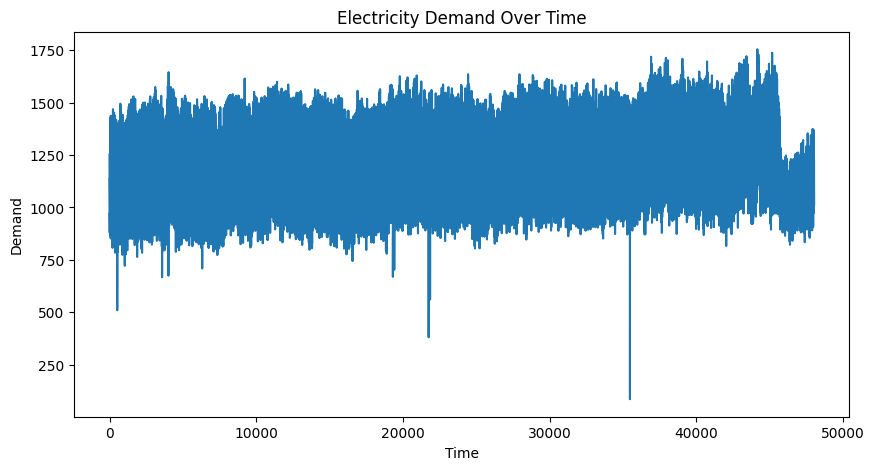

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(data['nat_demand'])
plt.title("Electricity Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (38438, 10)
Testing shape: (9610, 10)


In [10]:
from sklearn.ensemble import RandomForestRegressor

# create model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# train model
model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [11]:
# make predictions
y_pred = model.predict(X_test)

print("Predictions completed")

Predictions completed


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 44.90272057671565
RMSE: 61.247983001175506


In [16]:
# create lag features using the correct column name
data["lag_1"] = data["nat_demand"].shift(1)
data["lag_2"] = data["nat_demand"].shift(2)
data["lag_24"] = data["nat_demand"].shift(24)

# remove rows with missing values created by lagging
data = data.dropna()

print("Lag features created")

Lag features created


In [17]:
y = data["nat_demand"]

X = data[['T2M_toc','QV2M_toc','TQL_toc','W2M_toc',
          'hour','day','month','day_of_week',
          'holiday','school',
          'lag_1','lag_2','lag_24']]

In [18]:
print(data.columns)

Index(['datetime', 'nat_demand', 'T2M_toc', 'QV2M_toc', 'TQL_toc', 'W2M_toc',
       'T2M_san', 'QV2M_san', 'TQL_san', 'W2M_san', 'T2M_dav', 'QV2M_dav',
       'TQL_dav', 'W2M_dav', 'Holiday_ID', 'holiday', 'school', 'hour', 'day',
       'month', 'day_of_week', 'lag_1', 'lag_2', 'lag_24'],
      dtype='object')


In [19]:
# target
y = data["nat_demand"]

# input features
X = data[['T2M_toc','QV2M_toc','TQL_toc','W2M_toc',
          'hour','day','month','day_of_week',
          'holiday','school',
          'lag_1','lag_2','lag_24']]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained with lag features")

Model trained with lag features


In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 13.44176509434742
RMSE: 21.1675560145201


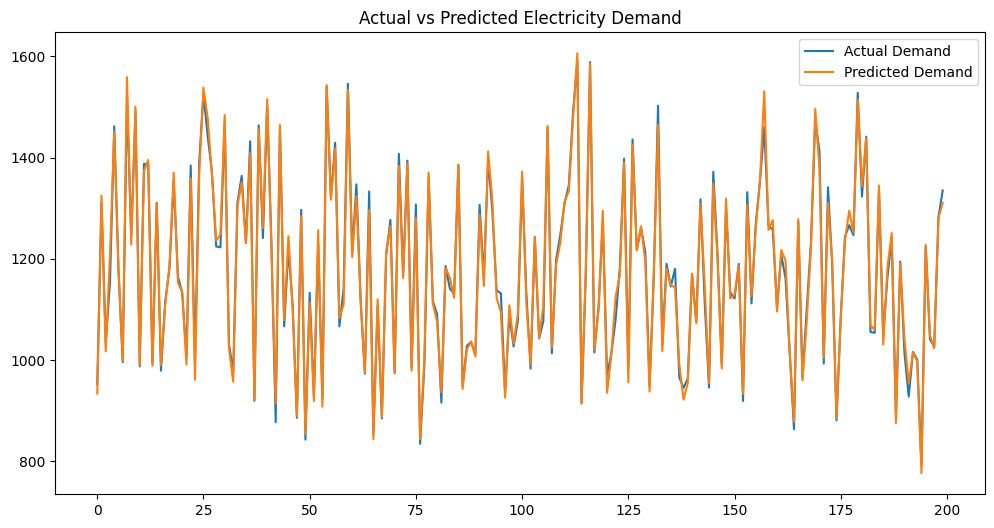

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values[:200], label="Actual Demand")
plt.plot(y_pred[:200], label="Predicted Demand")
plt.legend()
plt.title("Actual vs Predicted Electricity Demand")
plt.show()

lag_1          0.902127
hour           0.057963
lag_24         0.020407
lag_2          0.010014
day_of_week    0.002643
T2M_toc        0.001566
W2M_toc        0.001172
QV2M_toc       0.001004
TQL_toc        0.000951
month          0.000765
day            0.000759
holiday        0.000523
school         0.000106
dtype: float64


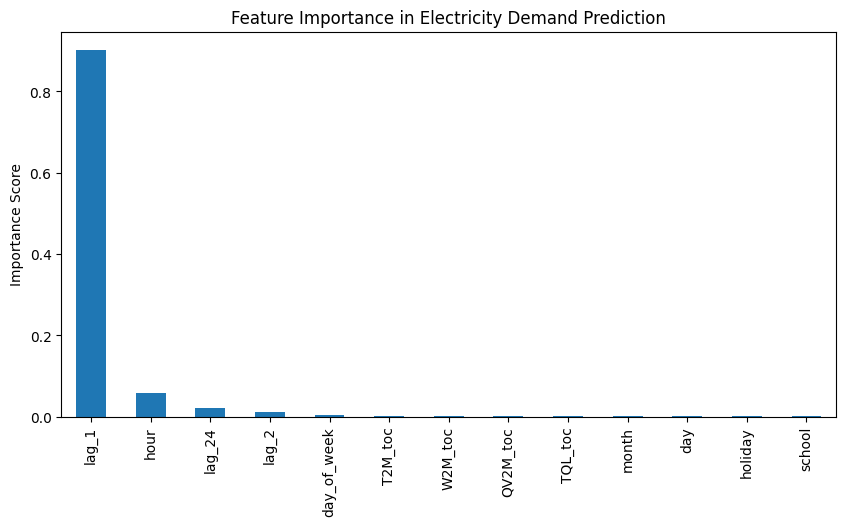

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# get feature importance
importance = model.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)

# sort
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)

# plot
plt.figure(figsize=(10,5))
feature_importance.plot(kind="bar")
plt.title("Feature Importance in Electricity Demand Prediction")
plt.ylabel("Importance Score")
plt.show()

In [26]:
peak_threshold = 1500  # adjust based on dataset

for value in y_pred[:50]:
    if value > peak_threshold:
        print("⚠ Peak demand expected:", value)

⚠ Peak demand expected: 1558.7492820000002
⚠ Peak demand expected: 1500.5091338895093
⚠ Peak demand expected: 1538.21811586377
⚠ Peak demand expected: 1515.366266999999


In [27]:
import joblib

joblib.dump(model, "model/load_forecast_model.pkl")

print("Model saved successfully")

Model saved successfully
